# Import libraries

In [141]:
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

## import the dataset

In [142]:
data_path = "titanic.csv"
def load_titanic_data():
    csv_path = data_path
    return pd.read_csv(csv_path, sep=',', low_memory=False)

In [143]:
titanic = load_titanic_data()

## Inspect Data

In [144]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [145]:
titanic.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [146]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [147]:
titanic.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [148]:
titanic.shape

(891, 12)

In [149]:
# Drop the column Name as it cannot be converted easily into a numeric value. Ticket will be dropped for the same reason. Cabin will be dropped as it has too many null observations.
titanic = titanic.drop(["Name", "Ticket", "Cabin", "PassengerId"], axis=1)

In [150]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [151]:
# Find numeric features with missing values
titanic.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

## Visualize the Data

array([[<Axes: xlabel='Survived', ylabel='Survived'>,
        <Axes: xlabel='Pclass', ylabel='Survived'>,
        <Axes: xlabel='Age', ylabel='Survived'>,
        <Axes: xlabel='SibSp', ylabel='Survived'>,
        <Axes: xlabel='Parch', ylabel='Survived'>,
        <Axes: xlabel='Fare', ylabel='Survived'>],
       [<Axes: xlabel='Survived', ylabel='Pclass'>,
        <Axes: xlabel='Pclass', ylabel='Pclass'>,
        <Axes: xlabel='Age', ylabel='Pclass'>,
        <Axes: xlabel='SibSp', ylabel='Pclass'>,
        <Axes: xlabel='Parch', ylabel='Pclass'>,
        <Axes: xlabel='Fare', ylabel='Pclass'>],
       [<Axes: xlabel='Survived', ylabel='Age'>,
        <Axes: xlabel='Pclass', ylabel='Age'>,
        <Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='SibSp', ylabel='Age'>,
        <Axes: xlabel='Parch', ylabel='Age'>,
        <Axes: xlabel='Fare', ylabel='Age'>],
       [<Axes: xlabel='Survived', ylabel='SibSp'>,
        <Axes: xlabel='Pclass', ylabel='SibSp'>,
        <Axes: xla

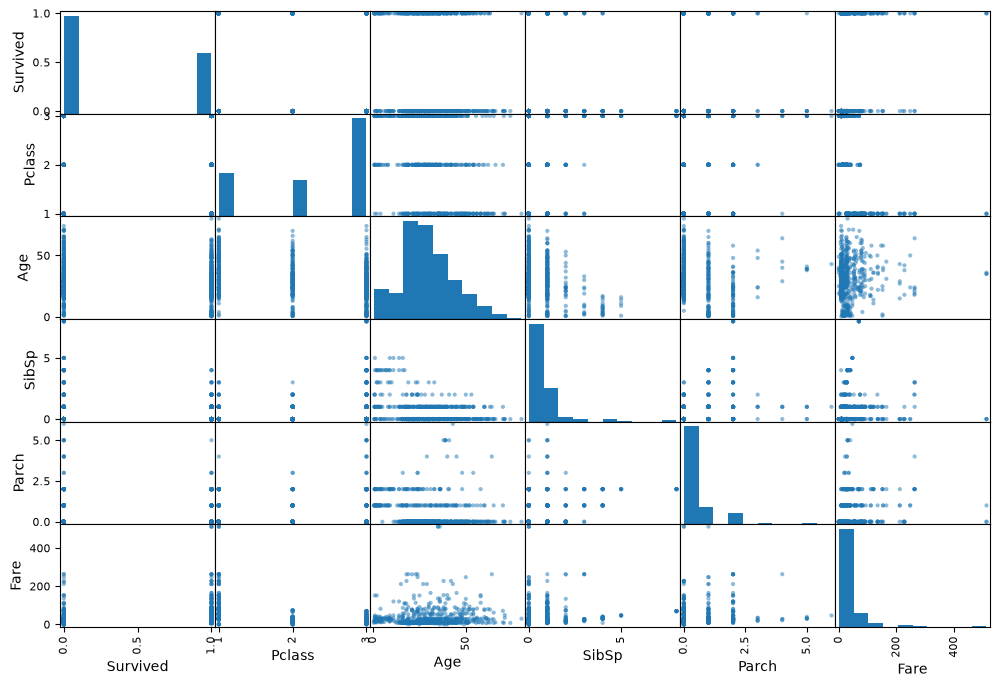

In [152]:
scatter_matrix(titanic[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Embarked"]], figsize=(12, 8))

## Preprocess the Data

In [153]:
# Fill in the missing age values with the median age
imputer = SimpleImputer(strategy="median")
imputer.fit(titanic[["Age"]])
titanic[["Age"]] = imputer.transform(titanic[["Age"]])

In [154]:
# Fill in the missing embarked values with the most frequent value
imputer = SimpleImputer(strategy="most_frequent")
imputer.fit(titanic[["Embarked"]])
titanic[["Embarked"]] = imputer.transform(titanic[["Embarked"]])

In [155]:
titanic.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [156]:
## Feature scaling and encoding

In [157]:
# Encode the string data into numerical data

cat_encoder = OneHotEncoder()
titanic[["Embarked"]] = cat_encoder.fit_transform(titanic[["Embarked"]])
titanic[["Sex"]] = cat_encoder.fit_transform(titanic[["Sex"]])


In [158]:
# Scale the data
scaler = StandardScaler()
scaler.fit(titanic[["Fare"]])
titanic[["Fare"]] = scaler.transform(titanic[["Fare"]])
scaler.fit(titanic[["Age"]])
titanic[["Age"]] = scaler.transform(titanic[["Age"]])


In [159]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,<Compressed Sparse Row sparse matrix of dtype ...,-0.565736,1,0,-0.502445,<Compressed Sparse Row sparse matrix of dtype ...
1,1,1,<Compressed Sparse Row sparse matrix of dtype ...,0.663861,1,0,0.786845,<Compressed Sparse Row sparse matrix of dtype ...
2,1,3,<Compressed Sparse Row sparse matrix of dtype ...,-0.258337,0,0,-0.488854,<Compressed Sparse Row sparse matrix of dtype ...
3,1,1,<Compressed Sparse Row sparse matrix of dtype ...,0.433312,1,0,0.420730,<Compressed Sparse Row sparse matrix of dtype ...
4,0,3,<Compressed Sparse Row sparse matrix of dtype ...,0.433312,0,0,-0.486337,<Compressed Sparse Row sparse matrix of dtype ...


In [160]:
titanic.describe().round()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.0,891.0,891.0,891.0,891.0,891.0
mean,0.0,2.0,0.0,1.0,0.0,0.0
std,0.0,1.0,1.0,1.0,1.0,1.0
min,0.0,1.0,-2.0,0.0,0.0,-1.0
25%,0.0,2.0,-1.0,0.0,0.0,-0.0
50%,0.0,3.0,-0.0,0.0,0.0,-0.0
75%,1.0,3.0,0.0,1.0,0.0,-0.0
max,1.0,3.0,4.0,8.0,6.0,10.0
